In [1]:
import os
os.makedirs('../reports', exist_ok=True)
print("✅ Reports directory ready!")

✅ Reports directory ready!


In [2]:
# ══════════════════════════════════════════════
# CELL 1 — Libraries aur models load
# ══════════════════════════════════════════════
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Models aur data load karo
xgb_model = joblib.load('../model/best_model.pkl')
X_test    = np.load('../model/X_test_scaled.npy')
y_test    = np.load('../model/y_test.npy')

# Feature names (preprocessing mein same order tha)
feature_names = [
    'RevolvingUtilization',   # Credit card usage %
    'Age',
    'Times30-59DaysLate',
    'DebtRatio',
    'MonthlyIncome',
    'OpenCreditLines',
    'Times90+DaysLate',
    'RealEstateLoans',
    'Times60-89DaysLate',
    'Dependents'
]

print("✅ Sab load ho gaya!")
print(f"Test samples: {X_test.shape[0]}")

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Sab load ho gaya!
Test samples: 30000


In [3]:
# ══════════════════════════════════════════════
# CELL 2 — SHAP Explainer banao
# ══════════════════════════════════════════════

# SHAP ka kaam:
# Prediction ke liye har feature ka contribution calculate karta hai
# e.g., "Age ne risk 20% badhaya, Income ne 15% ghataaya"

# Speed ke liye sirf 1000 samples lo (30000 bahut slow hoga)
X_sample = X_test[:1000]
X_df     = pd.DataFrame(X_sample, columns=feature_names)

# TreeExplainer XGBoost/RandomForest ke liye optimized hai
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_df)

print("✅ SHAP values calculate ho gaye!")
print("Shape:", shap_values.shape)  # (1000, 10) — 1000 samples, 10 features
print("\nSHAP values kya hain:")
print("Positive value = feature ne HIGH RISK ki taraf push kiya")
print("Negative value = feature ne LOW RISK ki taraf push kiya")

✅ SHAP values calculate ho gaye!
Shape: (1000, 10)

SHAP values kya hain:
Positive value = feature ne HIGH RISK ki taraf push kiya
Negative value = feature ne LOW RISK ki taraf push kiya


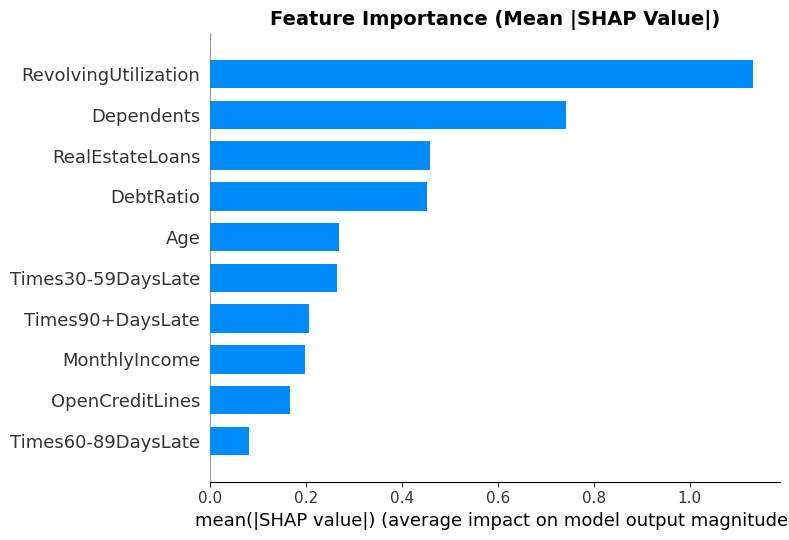

In [4]:
# ══════════════════════════════════════════════
# CELL 3 — Feature Importance (Bar Plot)
# ══════════════════════════════════════════════

# Mean absolute SHAP = overall feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_df,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("Feature Importance (Mean |SHAP Value|)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Expected result:
# 1. RevolvingUtilization — most important (credit usage zyada = risky)
# 2. Times90+DaysLate    — late payments bahut risky
# 3. Age                 — young log zyada risky
# 4. MonthlyIncome       — low income = risky

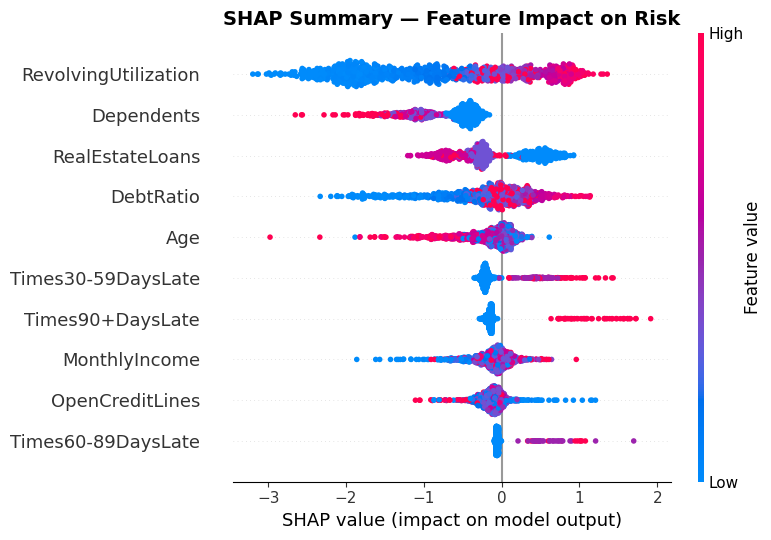

In [5]:
# ══════════════════════════════════════════════
# CELL 4 — SHAP Summary Beeswarm Plot
# ══════════════════════════════════════════════

# Yeh aur detail mein dikhata hai:
# - Har dot = ek sample
# - Color = feature value (red=high, blue=low)
# - X position = SHAP value (positive = pushes to high risk)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_df,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary — Feature Impact on Risk", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Kaise padhein:
# High RevolvingUtilization (red) + positive SHAP = zyada credit use karna = HIGH RISK
# High Age (red) + negative SHAP = umra zyada hona = LOW RISK

High-risk sample index: 7
Features:
RevolvingUtilization     1.374588
Age                      0.063792
Times30-59DaysLate      11.903983
DebtRatio               -1.415345
MonthlyIncome           -1.030486
OpenCreditLines         -1.552073
Times90+DaysLate        11.921405
RealEstateLoans         -0.769398
Times60-89DaysLate      11.958034
Dependents              -0.764275
Name: 7, dtype: float64


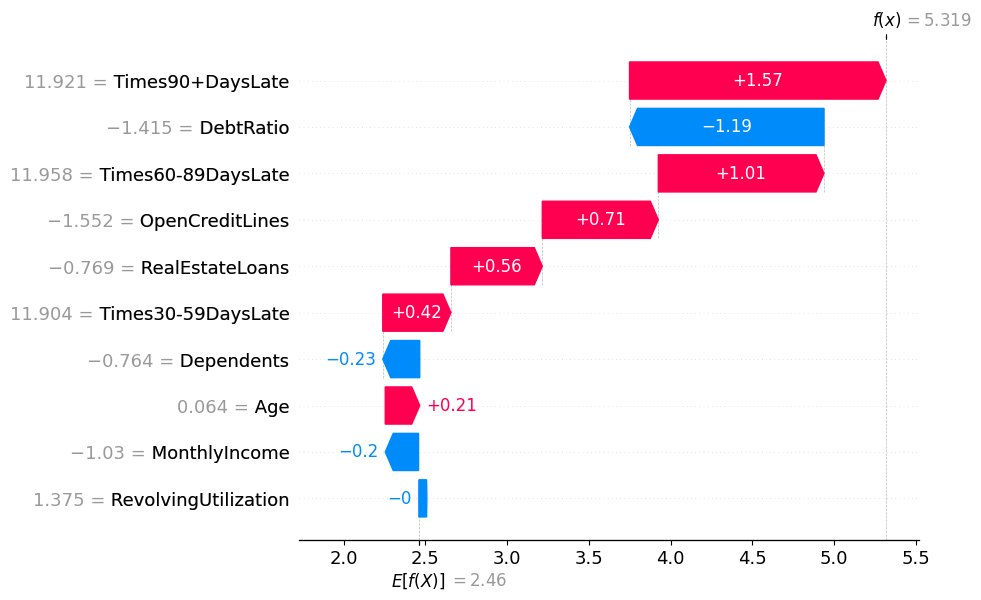

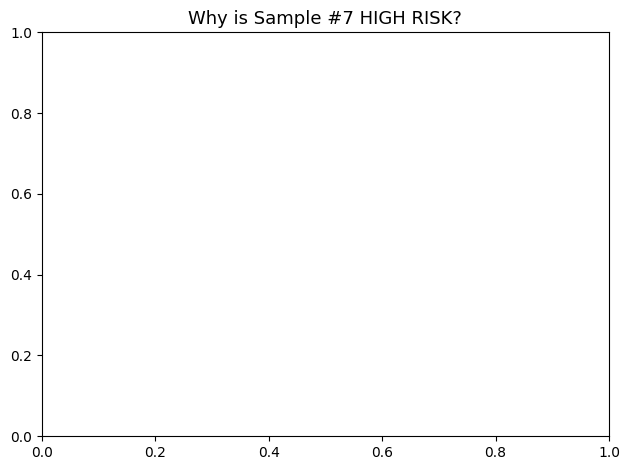

In [6]:
# ══════════════════════════════════════════════
# CELL 5 — Single Prediction Explain karo
# ══════════════════════════════════════════════

# Ek specific person ka prediction kyun hua — waterfall chart

# Pehle high-risk wala person dhundo
high_risk_idx = np.where(y_test[:1000] == 1)[0][0]

print(f"High-risk sample index: {high_risk_idx}")
print("Features:")
print(X_df.iloc[high_risk_idx])

# Waterfall plot — har feature ka contribution dikhata hai
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_df.iloc[high_risk_idx].values,
        feature_names=feature_names
    )
)
plt.title(f"Why is Sample #{high_risk_idx} HIGH RISK?", fontsize=13)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ══════════════════════════════════════════════
# CELL 6 — Force Plot (Interactive)
# ══════════════════════════════════════════════

# Yeh HTML mein interactive plot banata hai
shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_df.iloc[high_risk_idx],
    feature_names=feature_names
)

# Notebook mein dikhao
shap.save_html('../reports/shap_force_plot.html', force_plot)
print("✅ Force plot saved: ../reports/shap_force_plot.html")
print("Browser mein open karo is file ko — interactive hai!")

✅ Force plot saved: ../reports/shap_force_plot.html
Browser mein open karo is file ko — interactive hai!
